# Infectivity Per Mutation
Regress infectivitty results of constructs over mutations in those constructs to get mutation-level constribution to infectivity.

In [1]:
import pandas as pd
import torch
import pickle
from tqdm import tqdm
from sklearn.neighbors import KernelDensity as KDE
import numpy as np

import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pyro.set_rng_seed(0)

d = torch.float32
torch.set_default_dtype(d)

run_MCMC = True

## Read in neutralization data

In [3]:
# Neutralization
data_dir = 'data/Supp_Material/'
filename = 'Supp_TableS6_Neutralization_Data.csv'
neutralization = pd.read_csv(data_dir+filename)
neutralization = pd.melt(neutralization, id_vars='Name').rename(columns={'variable':'Pool', 'value':'Neutralization'})   # unpivot data
neutralization['Name'] = neutralization['Name'].apply(lambda x: x.capitalize() if x.islower() else x)   # clean up names to make sure VoCs match
neutralization['Neutralization'] = pd.to_numeric(neutralization['Neutralization'].apply(lambda x: 10 if x=='<20' else x))
neu_constructs = neutralization['Name'].unique()

# Rescale neutralization
neutralization = pd.merge(neutralization,
                           pd.read_csv('data/Supp_Material/Supp_TableS4_Infectivity_Data.csv', usecols=['Name', 'base_voc']).replace('BA.4/5', 'BA.5'),
                         on='Name')
neutralization = pd.merge(neutralization[['Name', 'Pool', 'base_voc', 'Neutralization']], 
                          neutralization[['Name', 'Pool', 'Neutralization']], 
                          left_on=['Pool', 'base_voc'], right_on=['Pool', 'Name'],
                          suffixes=[' - Construct', ' - Base'])
neutralization['Neutralization - Scaled'] = neutralization['Neutralization - Construct'] / neutralization['Neutralization - Base']
neutralization = neutralization.rename(columns={'Name - Construct':'Name', 'Name - Base':'Base VoC'})
neutralization = neutralization[['Name', 'Base VoC', 'Pool', 'Neutralization - Scaled']].drop_duplicates().reset_index(drop=True)

neutralization.head()

,Name,Base VoC,Pool,Neutralization - Scaled
0,WuG,WuG,Conv_Delta,1.000000
1,Alpha,WuG,Conv_Delta,1.484877
2,Gamma,WuG,Conv_Delta,0.639887
3,BA.1,WuG,Conv_Delta,0.018093
4,BA.2,WuG,Conv_Delta,0.092223


In [4]:
# Mutations
data_dir = 'data/Supp_Material/'
filename = 'construct_mutations.csv'
cols = ['Name', 'Designed mutations']
mutations = pd.read_csv(data_dir+filename, usecols=cols)
mutations['Name'] = mutations['Name'].apply(lambda x: x.capitalize() if x.islower() else x)    # name VoCs consistently
mutations['Designed mutations'] = mutations['Designed mutations'].apply(lambda x: x.replace(' ', ''))    # remove any spaces between mutations in the list
mutations = pd.concat([mutations, pd.DataFrame([{'Name':'WT', 'Designed mutations':None}])])

mutations = mutations[mutations['Designed mutations']!='--']

mut_constructs = mutations['Name'].unique()
mutations.head()

,Name,Designed mutations
4,WuG-4a,"T76I,M153S,Y473F,Q493R"
5,WuG-5a,"T76I,M153S,Y473F,N481T,Q493R"
6,WuG-2a,"T478K,R346T"
7,WuG-2b,"R346T,S494R"
8,WuG-2c,"R346T,K417V"


In [5]:
print('Disconnects:')
for n in set(neu_constructs) - set(mut_constructs):
    print(f'\tNeutralization but no mutations: {n}')
for n in set(mut_constructs) - set(neu_constructs):
    print(f'\tMutations but no neutralization: {n}')

Disconnects:
	Neutralization but no mutations: BQ.1.1
	Neutralization but no mutations: XBB.1
	Neutralization but no mutations: BA.5-2b
	Neutralization but no mutations: BQ.1
	Neutralization but no mutations: Gamma
	Neutralization but no mutations: XBB.1.5
	Neutralization but no mutations: BA.5
	Neutralization but no mutations: XBB
	Neutralization but no mutations: Alpha
	Neutralization but no mutations: Beta
	Neutralization but no mutations: WuG
	Neutralization but no mutations: BA.2.75
	Neutralization but no mutations: BA.2
	Neutralization but no mutations: BA.4
	Neutralization but no mutations: BA.2.12.1
	Neutralization but no mutations: Delta
	Neutralization but no mutations: BA.1
	Neutralization but no mutations: CH.1.1
	Neutralization but no mutations: SARS1
	Mutations but no neutralization: BA.5-2c
	Mutations but no neutralization: BA.5-1a
	Mutations but no neutralization: BA.5-1b
	Mutations but no neutralization: BA.5-1f
	Mutations but no neutralization: BA.2.12.1-8a
	Mutations

In [6]:
df = neutralization.merge(mutations, on='Name', how='inner')

df['Pool ID'] = df['Pool'].map({pool:i for i, pool in enumerate(df['Pool'].unique())})
df['Base VoC ID'] = df['Base VoC'].map({base:i for i, base in enumerate(df['Base VoC'].unique())})

print(f'{len(df)} neutralization results:')
df.head()

1709 neutralization results:


,Name,Base VoC,Pool,Neutralization - Scaled,Designed mutations,Pool ID,Base VoC ID
0,WuG-2a,WuG,Conv_Delta,0.955442,"T478K,R346T",0,0
1,WuG-2a,WuG,Conv_WT-1,1.054141,"T478K,R346T",1,0
2,WuG-2a,WuG,Conv_WT-2,1.024390,"T478K,R346T",2,0
3,WuG-2a,WuG,Conv_WT-3,1.156863,"T478K,R346T",3,0
4,WuG-2a,WuG,Vac_Mod-1,0.814651,"T478K,R346T",4,0


## QA Data

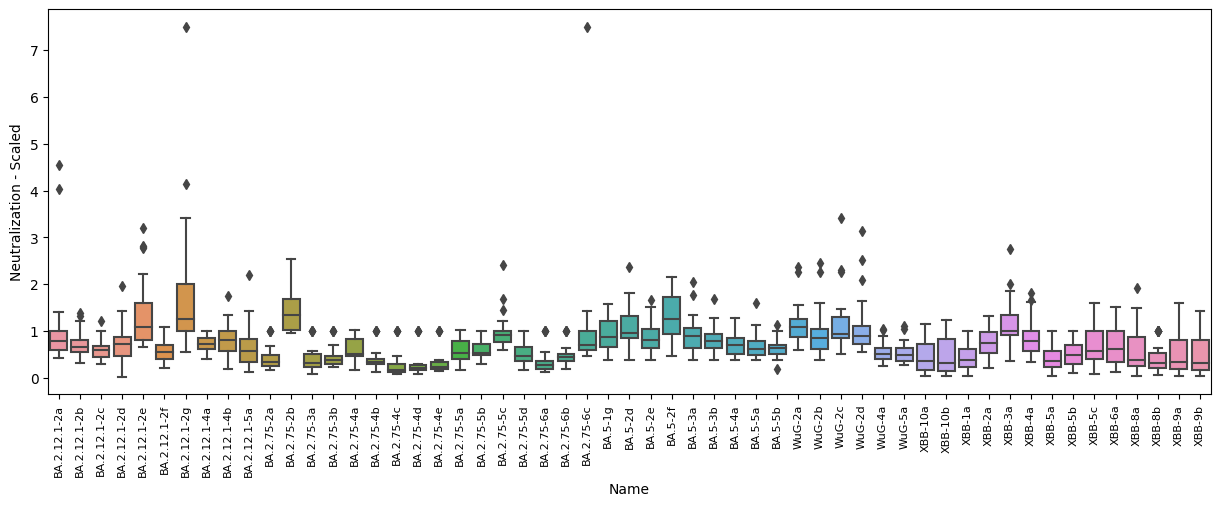

In [7]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot(x='Name',
            y='Neutralization - Scaled',
            # hue='Pool',
            data=df.sort_values(by='Name'),
            ax=ax)
ax.set_xticklabels(df.sort_values(by='Name')['Name'].unique(), rotation=90, fontsize=8);
# ax.legend(ncol=3);

In [8]:
# df[df['Neutralization - Scaled']>=15]

## Prepare model

In [9]:
def one_hot(mutations: pd.Series):
    features = list(set(','.join(filter(None, mutations.tolist())).split(',')))
    onehot = [[1 if mut.strip() in str(muts) else 0 for mut in features] for muts in mutations]
    
    return torch.tensor(onehot, dtype=d), features

In [10]:
# Model
def model(X,Y, pools):
    # model: Y = mX + b <--- b is different for each pool
    
    # Set hyperparameters
    μ_b = 2.
    σ_b = 3.
    μ_m0 = 1.
    σ_m0 = 1.
    σ_mp = 0.5
    
    σ = Y.std() / 2

        
    # Sample b for each pool
    # with pyro.plate("pools", len(set(pools))):
    b = pyro.sample("b", dist.Normal(μ_b, σ_b))
        
    # Sample coefficients for each mutation
    with pyro.plate("mutations", X.shape[1]):
        m0 = pyro.sample("m0", dist.Normal(μ_m0, σ_m0)).unsqueeze(1)
    # Sample coefficients for each pool
    with pyro.plate("pools", len(set(pools))):
        mp = pyro.sample("mp", dist.Normal(m0, σ_mp))
        
    # Make predictions
    pred_neutralization = torch.matmul(X,mp[:,pools]) + b
    
    # Score observation
    with pyro.plate("data", X.shape[0]):
        return pyro.sample("obs", dist.Normal(pred_neutralization, σ), obs=Y)

In [11]:
# import pyro
# from pyro import distributions as dist
# with pyro.plate("m", 12):    # 12 mutations
#     m0 = pyro.sample("m", dist.Normal(0,1))
# with pyro.plate("m1", 3):    # 3 pools
#     m1 = pyro.sample("m1", dist.Normal(m0, 0.001))
# m1

In [12]:
means=torch.tensor([0,1], dtype=torch.float32).unsqueeze(1)
means

tensor([[0.],
        [1.]])

In [13]:
import torch
with pyro.plate("a", 3):
    a = pyro.sample("a", dist.Normal(means, .0001))

In [14]:
a

tensor([[ 1.5410e-04, -2.9343e-05, -2.1788e-04],
        [ 1.0001e+00,  9.9989e-01,  9.9986e-01]])

In [15]:
means.shape

torch.Size([2, 1])

In [16]:
a[:,[0,0,0,1,2,1]]

tensor([[ 1.5410e-04,  1.5410e-04,  1.5410e-04, -2.9343e-05, -2.1788e-04,
         -2.9343e-05],
        [ 1.0001e+00,  1.0001e+00,  1.0001e+00,  9.9989e-01,  9.9986e-01,
          9.9989e-01]])

## Fit model

In [17]:
X, features = one_hot(df['Designed mutations'])
Y = torch.tensor(df['Neutralization - Scaled'].values, dtype=d)

In [18]:
model_dir = 'model_neutralization/'
chain_file = 'mcmc_chain.pkl'
features_file = 'mcmc_features.txt'
baselines_file = 'mcmc_baselines.txt'

if run_MCMC:
    nuts_kernel = NUTS(model)

    mcmc = MCMC(nuts_kernel, num_samples=2000, warmup_steps=2000)
    mcmc.run(X, Y, df['Pool ID'].tolist())

    posterior_samples = mcmc.get_samples()

    # Save
    with open(model_dir+chain_file, 'wb') as f:
        pickle.dump(posterior_samples, f)

    with open(model_dir+features_file, 'w') as f:
        f.writelines([f+'\n' for f in features])
        
    with open(model_dir+baselines_file, 'w') as f:
        f.writelines([b+'\n' for b in df['Pool'].unique()])
        
else:
    with open(model_dir+chain_file, 'rb') as f:
        posterior_samples = pickle.load(f)
    
    with open(model_dir+features_file, 'r') as f:
        features = f.read().split('\n')
        features.remove('')
        
    with open(model_dir+baselines_file, 'r') as f:
        baselines = f.read().split('\n')
        baselines.remove('')

Sample: 100%|████████████████████████████████████| 4000/4000 [25:59:54, 23.40s/it, step size=5.21e-02, acc. prob=0.873]


In [22]:
# Save
with open(model_dir+chain_file, 'wb') as f:
    pickle.dump(posterior_samples, f)

with open(model_dir+features_file, 'w') as f:
    f.writelines([f+'\n' for f in features])

with open(model_dir+baselines_file, 'w') as f:
    f.writelines([b+'\n' for b in df['Pool'].unique()])

## Inspect Traces

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ValueError: x and y can be no greater than 2D, but have shapes (2000,) and (2000, 24, 23)

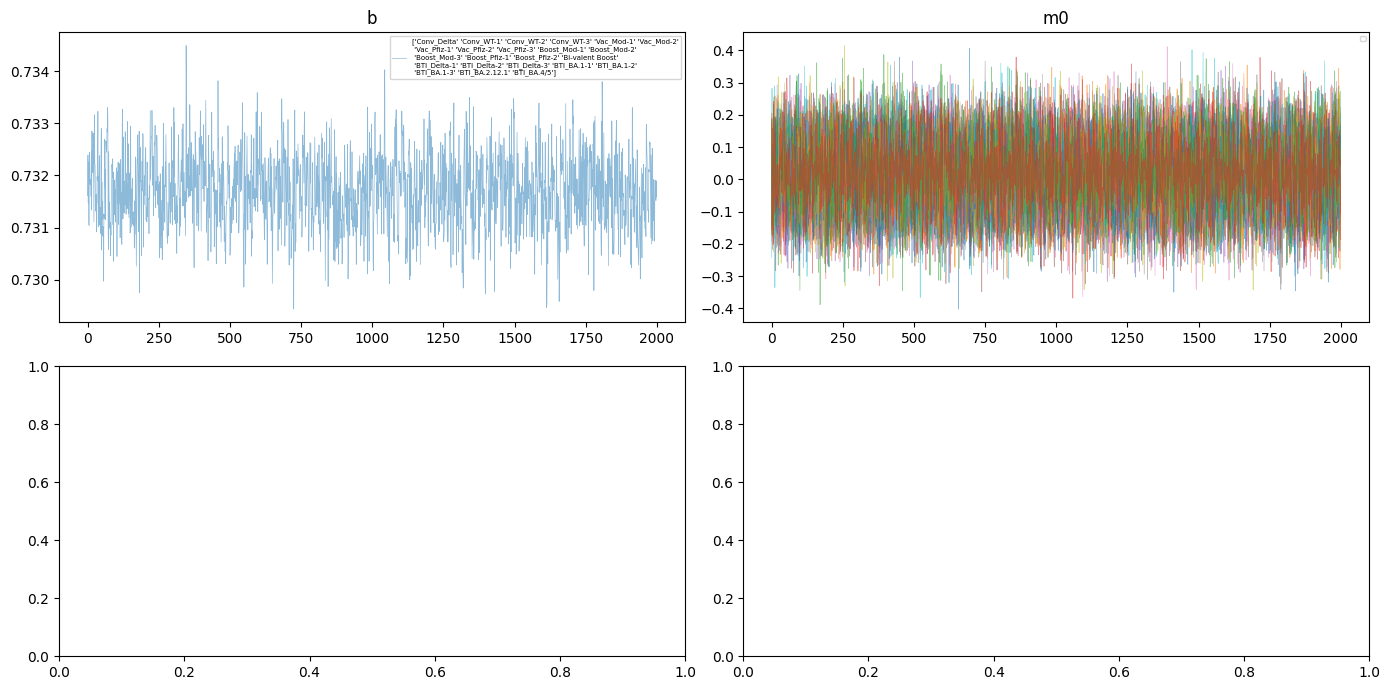

In [27]:
# Show all traces at once
def plot_trace(samples):
    num_trace = len(samples.keys())
    
    fig, axes = plt.subplots(round(num_trace/2), 2, figsize=(14, 7))
    axes = axes.flatten()
    
    def get_labels(k):
        if k=='b':
            return df['Pool'].unique()
        elif k=='m':
            return features
        
    for key, ax in zip(samples.keys(),axes):
        trace = samples[key]
        
        ax.plot(trace.detach().numpy(), label=get_labels(key), linewidth=0.5, alpha=0.5)
        ax.set_title(key)
        ax.legend(ncol=5, fontsize=5)
        
        fig.tight_layout()
        
plot_trace(posterior_samples)

In [20]:
def dropdown_plot(data_dict):
    def setup():
        # Initialize Plotly for Jupyter Notebook
        init_notebook_mode(connected=True)
    def initialize_plot(data_dict):
        # Create a list of names from the dictionary keys
        names = list(data_dict.keys())
        # Create the initial scatter plot
        initial_name = names[0]  # Initial name to display
        initial_data = data_dict[initial_name]

        trace = go.Scatter(
            x=list(range(len(initial_data))),
            y=initial_data,
            mode='markers',
            name=initial_name
        )

        layout = go.Layout(
            title='Convergence of MCMC Traces',
            xaxis=dict(title='Sample'),
            yaxis=dict(title='Value')
        )

        fig = go.Figure(data=[trace], layout=layout)
        return fig

    def dropdown(data_dict, fig):
        # Create the dropdown menu
        updatemenu = []
        buttons = []

        for name in list(data_dict.keys()):
            data = data_dict[name]
            button = {
                'label': name,
                'method': 'update',
                'args': [{'x': [list(range(len(data)))], 'y': [data], 'name': name}]
            }
            buttons.append(button)

        updatemenu = [
            {
                'buttons': buttons,
                'direction': 'down',
                'showactive': True,
                'x': 0,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            }
        ]

        fig.update_layout(showlegend=True, updatemenus=updatemenu)
        return fig

    fig = initialize_plot(data_dict)
    fig = dropdown(data_dict, fig)
    
    return fig

In [21]:
all_samples = torch.cat([posterior_samples['m'], posterior_samples['b']], dim=1)
all_labels = [f'm_{f}' for f in features] + [f'Baseline ({p})' for p in df['Pool'].unique()]

trace_dict = {all_labels[i]: all_samples[:,i]
             for i in range(len(all_labels))}
# for i in range(all_samples.shape[0]):
#     trace_dict[all_labels[i]] = posterior_samples['m'][i,:]

fig = dropdown_plot(trace_dict)
iplot(fig)
fig.write_html('figs/neutralization_mcmc_traces.html')

KeyError: 'm'

## Visualize Coefficients

In [ ]:
def preprocess_kde(samples, labels):
    m_samples = samples['m']
    b_samples = samples['b']
    all_samples = torch.cat((m_samples, b_samples), dim=1)  # put β at the end
    coefficients = labels.copy()
    sort_by = all_samples.mean(dim=0)
    sort_by = sort_by[:-1]  # intercept is the last term in this tensor
    coef_map = {x:i for i, (_,x) in enumerate(sorted(zip(sort_by, labels), reverse=True))}
    # Add intercept term last
    for i, p in enumerate(df['Pool'].unique()):
        coefficients.append(f'Baseline ({p})')
        coef_map[f'Baseline ({p})'] = len(coefficients) -1
    # coefficients.append([f'Baseline ({p})' for p in df['Pool'].unique()])
    # coef_map['Baseline (WuD)'] = len(coefficients)-1
    return all_samples, coefficients, coef_map

def setup(fig, axes, samples):
    options = {}
    options['scale'] = 1
    options['xlim'] = [-600, 1000]
    options['ymax'] = samples.shape[1]
    
    axes[1].spines.right.set_visible(False)
    axes[1].spines.left.set_visible(False)
    axes[1].spines.top.set_visible(False)
    axes[1].set_yticks([])
    axes[1].set_yticklabels([])
    
    axes[0].axis('off')
    axes[2].axis('off')
    
    plt.rcParams['font.family'] = ['Times New Roman']
    return options

def plot_kdes(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    xlim = options['xlim']
    num_points = 1000
    color='blue'
    
    linecolor = 'blue'
    linewidth = 0.7
    
    for i, coef in tqdm(enumerate(coefficients)):
        base_y = (ymax - coef_map[coef])  # coef_map[coef]  
        sample_idx = i
        # Fit KDE
        s = samples[:, sample_idx]
        kde = KDE(kernel='gaussian', bandwidth=0.01).fit(s.reshape(-1,1))
        x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
        # Generate KDE curve
        y = np.exp(kde.score_samples(x))
        # Scale curve
        y /= (scale*max(y))
        # Move y up to the desired height
        y += base_y
        
        
        ax.plot(x, y, 
                color=color, linewidth=linewidth)
        
    ax.set_xlim(xlim)
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Posterior', loc='center')
    
    
def annotate_posterior(ax, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    pos = [ymax - i for i in range(ymax)]
    labels = list(coef_map.keys())
    for y, t in zip(pos, labels):
        ax.text(1, y, t,
                ha='right')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Mutations', loc='right')
    
def annotate_means(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    coefs = list(coef_map.keys())
    for i, c in enumerate(coefficients):
        mean = samples[:,i].mean()
        t = '{:6.2f}'.format(mean)
        y = ymax - coef_map[c]
        ax.text(0, y, t,
                ha='left')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Means', loc='left')
    
def affordances(ax, options):
    ax.vlines(0, 0, options['ymax']+options['scale'],
             color='gray', linewidth=0.5, alpha=0.5)
    ax.vlines(1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.vlines(-1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.text(0, options['ymax']+options['scale'], '0', ha='center', va='bottom', fontsize=6)
    ax.text(1, options['ymax']+options['scale'], '+1', ha='center', va='bottom', fontsize=6)
    ax.text(-1, options['ymax']+options['scale'], '-1', ha='center', va='bottom', fontsize=6)

In [ ]:
all_samples, coefficients, coefficient_map = preprocess_kde(posterior_samples, features)

fig, axes = plt.subplots(1, 3, figsize=(10, 30), gridspec_kw={'width_ratios': [1, 2, 1]})

options = setup(fig, axes, all_samples)
plot_kdes(axes[1], all_samples, coefficients, coefficient_map, options)
annotate_posterior(axes[0], coefficients, coefficient_map, options)
annotate_means(axes[2], all_samples, coefficients, coefficient_map, options)
affordances(axes[1], options)

fig.tight_layout()
fig.savefig('figs/infectivity_posterior_with_annotations.png', dpi=150)

## Save Coefficients

In [ ]:
# Create a CSV with results
outfile = 'results/mutation_neutralization_effects.csv'
results = pd.DataFrame({'Mutation':features, 'Mean':posterior_samples['m'].mean(dim=0), 'Std':posterior_samples['m'].std(dim=0)}).sort_values(by='Mean', ascending=False).reset_index(drop=True)
results.to_csv(outfile, index=False)

outfile = 'results/baseline_neutralization_effects.csv'
constants = pd.DataFrame({'Pool':df['Pool'].unique(), 'Mean':posterior_samples['b'].mean(dim=0), 'Std':posterior_samples['b'].std(dim=0)}).sort_values(by='Mean', ascending=False).reset_index(drop=True)
constants.to_csv(outfile, index=False)

print('Top mutations:')
display(results.head())
print('Bottom mutations:')
display(results.tail())